In [ ]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List,Literal
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel,Field
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


In [103]:
load_dotenv()

True

In [104]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [105]:
docs=(
    PyPDFLoader("./Documents/Company_Policies.pdf").load()+
    PyPDFLoader("./Documents/Company_Profile.pdf").load()+
    PyPDFLoader("./Documents/Product_and_pricing.pdf").load()
)

In [106]:
chunks=RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)

In [107]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [108]:
vector_store=FAISS.from_documents(chunks,embeddings)

In [109]:
rtriever=vector_store.as_retriever(search_kwargs={"k":3})

In [110]:
class State(TypedDict):
    question:str
    need_retrieval:bool

    docs:List[Document]
    relevant_docs:List[Document]

    context:str
    answer:str

    issup:Literal["fully_supported", "partially_supported", "no_support"]
    evidence:List[str]

In [111]:
class RetrieveDecision(BaseModel):
    should_retrieve:bool=Field(
        description="True if exteral documentds are needed to answer reliably,else false."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm=llm.with_structured_output(RetrieveDecision)

In [112]:
def decide(state:State):
    descision:RetrieveDecision=should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state['question'])
    )
    return {
        "need_retrieval":descision.should_retrieve
    }

In [113]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate(state:State):
    out=llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer":out.content
    }

In [114]:
def retrieve(state:State):
    return {
        "docs":rtriever.invoke(state["question"])
    }

In [115]:
class RelevenceDecision(BaseModel):
    is_relevant:bool=Field(
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevence_llm=llm.with_structured_output(RelevenceDecision)

def is_relevent(state:State):
    relevant_docs :List[Document]=[]

    for doc in state["docs"]:
        descision:RelevenceDecision=relevence_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if descision.is_relevant:
            relevant_docs.append(doc)

    return {
        "relevant_docs":relevant_docs 
    }

In [116]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

In [117]:
def generate_from_contex(state:State):
    context="\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {
            "answer":"No relevant document found.",
            "context": ""
        }
    
    out=llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {
        "answer":out.content,
        "context":context
    }

In [118]:
def no_answer_docs(state:State):
    return {
        "answer": "No relevant document found.",
        "context": ""
    }

In [119]:
class IsSUPDescision(BaseModel):
    issup:Literal["fully_supported", "partially_supported", "no_support"]
    evidence:List[str]=Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_llm=llm.with_structured_output(IsSUPDescision)

In [ ]:
def is_sup(state:State):
    descision:IsSUPDescision=issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return {
        "issup":descision.issup,
        "evidence":descision.evidence
    }

In [121]:
def route_after_decide(state:State)->Literal["Generate","Retrieve"]:
    if state["need_retrieval"]:
        return "Retrieve"
    return "Generate"

In [122]:
def route_after_relevence(state:State)->Literal["From Relevent Docs","No Relevent Docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "From Relevent Docs"
    return "No Relevent Docs"

In [123]:
g=StateGraph(State)

g.add_node("Decide",decide)
g.add_node("Generate",generate)

g.add_node("Relevent",is_relevent)
g.add_node("Retrieve",retrieve)

g.add_node("From Relevent Docs",generate_from_contex)
g.add_node("No Relevent Docs",no_answer_docs)

g.add_node("Is Supportive",is_sup)



g.add_edge(START,"Decide")
g.add_conditional_edges(
    "Decide",
    route_after_decide,
    {
        "Retrieve":"Retrieve",
        "Generate":"Generate"
    }
)

g.add_edge("Generate",END)

g.add_edge("Retrieve","Relevent")

g.add_conditional_edges(
    "Relevent",
    route_after_relevence,
    {
        "From Relevent Docs":"From Relevent Docs",
        "No Relevent Docs":"No Relevent Docs"
    }
)
g.add_edge("From Relevent Docs","Is Supportive")

g.add_edge("Is Supportive",END)
g.add_edge("No Relevent Docs",END)

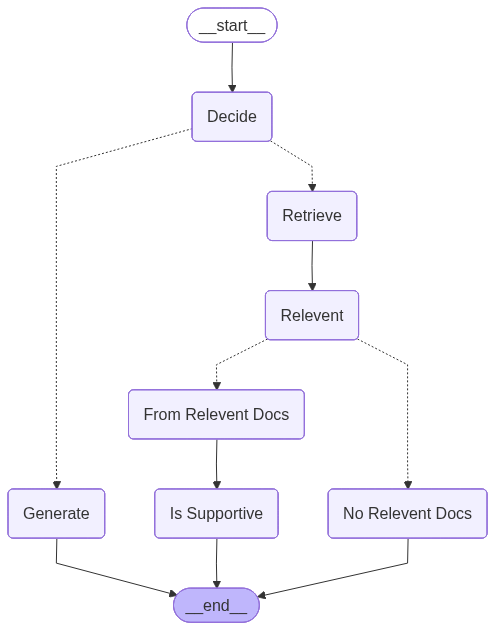

In [124]:
app=g.compile()
app

In [125]:
result = app.invoke(
        {
            "question": 'How many employees does NexaAI have?',
            "docs": [],
            "relevant_docs": [],
            "context": "",
            "answer": "",
            "issup": "",
            "evidence": [],
        },
    )

print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: True
#docs: 3
#relevant_docs: 1
issup: fully_supported
evidence: ['Employees: 85+']
answer: NexaAI has 85+ employees.


In [126]:
result['need_retrieval']

True

In [127]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision
****************************************************************************************************
Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Fo

In [128]:
from pprint import pprint
pprint(result)

{'answer': 'NexaAI has 85+ employees.',
 'context': 'NexaAI Solutions – Company Profile\n'
            'Company Overview\n'
            'NexaAI Solutions Pvt. Ltd. is a business-focused artificial '
            'intelligence company founded in 2021.\n'
            'The company specializes in building enterprise-ready AI systems '
            'for knowledge management,\n'
            'analytics, and automation.\n'
            'NexaAI primarily serves mid-sized and large organizations across '
            'technology, finance, healthcare,\n'
            'and education sectors.\n'
            '\x7f\n'
            'Founded: 2021\n'
            '\x7f\n'
            'Headquarters: Bengaluru, India\n'
            '\x7f\n'
            'Employees: 85+\n'
            '\x7f\n'
            'Operating Regions: India, Southeast Asia, Europe\n'
            'Vision',
 'docs': [Document(id='fbb8edcb-c0cd-4263-8db4-0f9b57e89bce', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creato